In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import time
import itertools
from joblib import Parallel, delayed

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Data

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_CRASH_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

#df = df[df['bull_market']==1]

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

2026-03-10 15:10:29.648 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/10 15:10:30 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.147 instead (on interface en0)
26/03/10 15:10:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-bdec029f-b3e1-4932-833f-10aa8b0d8858;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 68ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	| 

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/10 15:10:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
2026-03-10 15:10:32.862 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (663262, 33)
Years: 1990


In [3]:
class OHLCResampler:
    def __init__(self, data, date_col="Date", ticker_col="Ticker"):
        self.data = data.copy()
        self.date_col = date_col
        self.ticker_col = ticker_col

        # S'assurer que la colonne de date est bien en datetime
        self.data[date_col] = pd.to_datetime(self.data[date_col])
        self.data.set_index(date_col, inplace=True)

    def resample(self, period='W'):
        grouped = self.data.groupby(self.ticker_col)

        resampled = grouped.resample(period).agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).reset_index()

        return resampled

# Backtest

## Top n Portfolio

In [4]:
import pandas as pd
import numpy as np

def generate_top_n_portfolio_with_ma_filter(
    df, 
    momentum_window=12, 
    top_n=10, 
    rebalance_freq='W', 
    ma_fast_window=12, 
    ma_slow_window=56,
    stock_ma_window=26  # 👈 NOUVELLE VARIABLE : Fenêtre de la moyenne mobile pour chaque action
):
    """
    Sélectionne le Top N basé sur le momentum.
    FILTRE MACRO : Passe en Cash si le S&P 500 est dans une mauvaise configuration.
    FILTRE MICRO : N'achète une action que si son Prix > Moyenne Mobile Individuelle.
    """
    # ==========================================
    # 📊 1. CALCUL DES MOYENNES MOBILES DU MARCHÉ
    # ==========================================
    market_data = df[['date', 'adjClose_GSPC']].drop_duplicates().sort_values('date').copy()
    
    market_data['ma_fast'] = market_data['adjClose_GSPC'].rolling(window=ma_fast_window).mean()
    market_data['ma_slow'] = market_data['adjClose_GSPC'].rolling(window=ma_slow_window).mean()
    
    cond_bull = (market_data['ma_fast'] > market_data['ma_slow']) & (market_data['adjClose_GSPC'] > market_data['ma_slow'])
    cond_bear = (market_data['ma_fast'] <= market_data['ma_slow']) & (market_data['adjClose_GSPC'] > market_data['ma_fast'])
    
    is_invested = cond_bull | cond_bear
    market_data['go_to_cash'] = np.where(is_invested, 0, 1)

    # ==========================================
    # 📈 2. PRÉPARATION DES DONNÉES ACTIONS
    # ==========================================
    stock_data = df[df['symbol'] != '^GSPC'][['symbol', 'date', 'adjClose']].copy()
    data = stock_data.merge(market_data[['date', 'go_to_cash']], on='date', how='left')
    data = data.sort_values(['symbol', 'date'])

    # --- 3. Calcul du Momentum, Rendement Futur ET Moyenne Mobile Individuelle ---
    data['Momentum'] = data.groupby('symbol')['adjClose'].pct_change(periods=momentum_window)
    data['NextReturn'] = data.groupby('symbol')['adjClose'].shift(-1) / data['adjClose'] - 1
    
    # 👈 NOUVEAU : Calcul de la MA pour chaque action séparément
    data['Stock_MA'] = data.groupby('symbol')['adjClose'].transform(lambda x: x.rolling(window=stock_ma_window).mean())

    # --- 4. Gestion des dates de rebalancement ---
    if rebalance_freq == 'W':
        data['is_rebalance_date'] = True
    else:
        if rebalance_freq == 'M':
            data['Period'] = data['date'].dt.to_period('M')
        elif rebalance_freq == 'Q':
            data['Period'] = data['date'].dt.to_period('Q')
        elif rebalance_freq == '6M':
            data['Period'] = data['date'].dt.year.astype(str) + "H" + np.where(data['date'].dt.month <= 6, '1', '2')
        elif rebalance_freq == 'Y':
            data['Period'] = data['date'].dt.to_period('Y')
            
        rebalance_dates = data.groupby('Period')['date'].transform('max')
        data['is_rebalance_date'] = (data['date'] == rebalance_dates)

    # --- 5. RANKING (Top N) avec FILTRE MICRO ---
    # On s'assure d'avoir suffisamment d'historique pour le momentum ET la moyenne mobile
    reb_data = data[data['is_rebalance_date']].dropna(subset=['Momentum', 'Stock_MA']).copy()
    
    # 🛡️ NOUVEAU FILTRE : On élimine impitoyablement les actions sous leur MA
    reb_data = reb_data[reb_data['adjClose'] > reb_data['Stock_MA']]
    
    reb_data['Rank'] = reb_data.groupby('date')['Momentum'].rank(method='first', ascending=False)
    buys = reb_data[reb_data['Rank'] <= top_n].copy()
    
    # Note : S'il y a moins de 'top_n' actions qui passent le filtre, 
    # une partie du portefeuille restera automatiquement en cash (poids 0).
    buys['Base_Weight'] = 1.0 / top_n

    # --- 6. Intégration et Propagation ---
    data = data.merge(buys[['symbol', 'date', 'Base_Weight']], on=['symbol', 'date'], how='left')
    data.loc[data['is_rebalance_date'] & data['Base_Weight'].isna(), 'Base_Weight'] = 0.0
    data['Base_Weight'] = data.groupby('symbol')['Base_Weight'].ffill().fillna(0.0)

    # ==========================================
    # 🛡️ 7. APPLICATION DU FILTRE CASH MACRO
    # ==========================================
    data['Target_Weight'] = np.where(data['go_to_cash'] == 1, 0.0, data['Base_Weight'])
    data = data.dropna(subset=['NextReturn'])

    return data

## Vectorized Backtester

In [5]:
def run_vectorized_backtest(data, transaction_cost=0):
    """
    Calcule la performance globale et compte le nombre de trades par semaine.
    """
    data['Weight_Change'] = data.groupby('symbol')['Target_Weight'].diff().fillna(data['Target_Weight'])
    data['Cost'] = data['Weight_Change'].abs() * transaction_cost
    data['Strat_Return'] = data['Target_Weight'] * data['NextReturn']
    
    # 🆕 COMPTAGE DES TRADES
    # On utilise un petit seuil (0.001) pour éviter les bugs de précision des flottants en Python
    data['is_buy'] = (data['Weight_Change'] > 0.001).astype(int)
    data['is_sell'] = (data['Weight_Change'] < -0.001).astype(int)
    
    # Agrégation au niveau du Portefeuille
    port_returns = data.groupby('date')[['Strat_Return', 'Cost']].sum()
    trade_counts = data.groupby('date')[['is_buy', 'is_sell']].sum()
    
    # On fusionne les rendements et le comptage des trades
    port_returns = port_returns.join(trade_counts)
    
    port_returns['Net_Return'] = port_returns['Strat_Return'] - port_returns['Cost']
    port_returns['Capital'] = (1 + port_returns['Net_Return']).cumprod()
    
    return port_returns

## Running only one combination

In [6]:
def run_single_backtest(params, df_source, start_date, end_date):
    # 1. Nouveaux paramètres épurés (uniquement ce qui concerne le Stock Picking)
    mom_win, top_n, reb_freq, ma_fast_window, ma_slow_window, stock_ma_window = params

    default_output = {
        "Momentum_Window": mom_win, 
        "Top_N": top_n,
        "Rebalance": reb_freq,
        "MA_fast_Window": ma_fast_window,
        "MA_slow_Window": ma_slow_window,
        "MA_stock":stock_ma_window,
        "Total Return": np.nan, 
        "CAGR": np.nan,
        "Calmar Ratio": np.nan,
        "Max Drawdown": np.nan,
        "Sharpe Ratio": np.nan, 
        "Error": None
    }

    try:
        # 🛠️ CORRECTION : Le nom de la fonction est maintenant correct
        full_signals = generate_top_n_portfolio_with_ma_filter(
            df_source, 
            momentum_window=mom_win, 
            top_n=top_n, 
            rebalance_freq=reb_freq,
            ma_fast_window=ma_fast_window,
            ma_slow_window=ma_slow_window,
            stock_ma_window=stock_ma_window
        )

        # 3. Filtre des dates de test
        mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
        backtest_data = full_signals.loc[mask]

        if backtest_data.empty:
            default_output["Error"] = "No data in timeframe"
            return default_output

        # 4. Lancement du Backtest Vectorisé 
        res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.005)

        # 5. Calcul des métriques
        total_return = res_df['Capital'].iloc[-1] - 1
        n_years = (res_df.index[-1] - res_df.index[0]).days / 365.25
        cagr = (res_df['Capital'].iloc[-1]) ** (1 / max(1, n_years)) - 1
        
        rolling_max = res_df['Capital'].cummax()
        max_dd = ((res_df['Capital'] - rolling_max) / rolling_max).min()
        
        mean_ret = res_df['Net_Return'].mean()
        std_ret = res_df['Net_Return'].std()
        sharpe = (mean_ret / std_ret) * np.sqrt(52) if std_ret > 0 else 0
        calmar = abs(cagr/max_dd)

        # Mise à jour de l'output
        output = default_output.copy()
        output.update({
            "Total Return": total_return, 
            "CAGR": cagr,
            "Calmar Ratio": calmar,
            "Max Drawdown": max_dd, 
            "Sharpe Ratio": sharpe
        })
        return output

    except Exception as e:
        default_output["Error"] = str(e)
        return default_output

## Grid Search

In [7]:
def grid_search_execution(df, param_grid, start_date, end_date):
    keys, values = zip(*param_grid.items())
    combinations = [v for v in itertools.product(*values)]

    print(f"🚀 Lancement de la Grid Search sur {len(combinations)} combinaisons...")
    start_time = time.time()

    # Exécution en parallèle sur tous les coeurs du processeur (n_jobs=-1)
    results_list = Parallel(n_jobs=-1)(
        delayed(run_single_backtest)(params, df, start_date, end_date) for params in combinations
    )

    end_time = time.time()
    print(f"✅ Terminé en {end_time - start_time:.2f} secondes.")

    results_df = pd.DataFrame(results_list)
    
    # On affiche les 10 meilleures stratégies triées par Sharpe Ratio
    best_strats = results_df[results_df['Error'].isna()].sort_values(by='Sharpe Ratio', ascending=False)
    return best_strats

## Running Backtest

In [69]:
# Définition de la grille de paramètres (Stock Picking pur)
param_grid = {
    'momentum_window': [4, 12, 26, 52],   # 1 mois, 3 mois, 6 mois, 1 an
    'top_n': [5, 10],         # Portefeuille très concentré vs très diversifié
    'rebalance_freq': ['W', 'M', 'Q', '6M', 'Y'],
    'ma_fast_window': [26], 
    'ma_slow_window': [50],
    'stock_ma_window': [15, 20]
}

# Lancement de la Grid Search
best_strategies_df = grid_search_execution(
    df=df,  # Ton DataFrame source
    param_grid=param_grid,
    start_date='1980-01-01',
    end_date='2026-01-01'
)

🚀 Lancement de la Grid Search sur 80 combinaisons...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

✅ Terminé en 8.57 secondes.


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume


🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE ---
Momentum: 52 | Top N: 5 | Rebalance: 6M


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Weight_Change'] = data.groupby('symbol')['Target_Weight'].diff().fillna(data['Target_Weight'])
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cost'] = data['Weight_Change'].abs() * transaction_cost
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11867/3037643446.py:7: SettingWith

date
1990-01-05   -0.009756
1990-01-11    0.003513
1990-01-12   -0.024675
1990-01-19    0.002839
1990-01-26   -0.000859
                ...   
2025-11-28    0.005355
2025-12-05    0.001934
2025-12-12   -0.010664
2025-12-19    0.008818
2025-12-26   -0.000301
Name: GSPC_Return, Length: 2368, dtype: float64

📋 --- APERÇU DES 15 DERNIÈRES POSITIONS DU PORTEFEUILLE ---
      date symbol Poids_Alloué Rendement_Réalisé
1991-07-12     HD        20.0%            -3.25%
1991-07-12    PFE        20.0%             4.05%
1991-07-12     CB        20.0%             1.75%
1991-07-12     MO        20.0%             -2.9%
1991-07-12    GPS        20.0%             2.32%
1991-07-05    PFE        20.0%              3.5%
1991-07-05     HD        20.0%             3.36%
1991-07-05     MO        20.0%             3.37%
1991-07-05    GPS        20.0%             5.71%
1991-07-05     CB        20.0%             0.94%
1991-06-28     HD        20.0%              4.2%
1991-06-28    PFE        20.0%              0

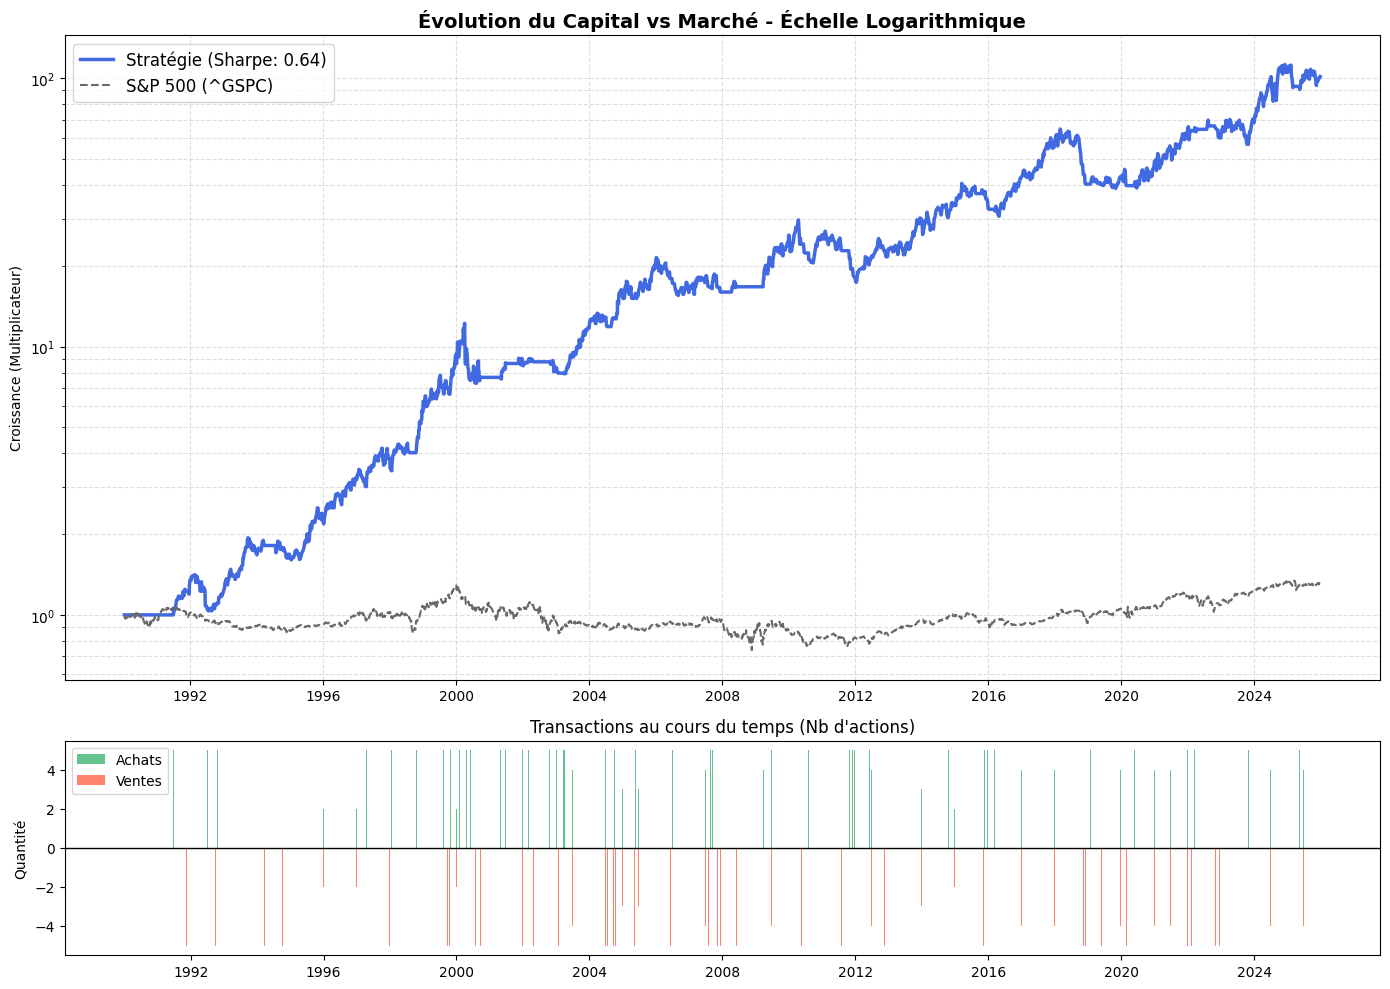

In [70]:
import matplotlib.pyplot as plt

def analyze_best_strategy(best_df, df_source, start_date, end_date):
    if best_df.empty:
        print("❌ Aucune stratégie valide trouvée.")
        return None, None
        
    # 1. Extraction des paramètres de la ligne n°1
    best_params = best_df.sort_values(by='CAGR', ascending=False).iloc[0]
    print("\n🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE ---")
    print(f"Momentum: {best_params['Momentum_Window']} | Top N: {best_params['Top_N']} | Rebalance: {best_params['Rebalance']}")
    
    # 2. Génération des signaux
    full_signals = generate_top_n_portfolio_with_ma_filter(
        df_source, 
        momentum_window=int(best_params['Momentum_Window']), 
        top_n=int(best_params['Top_N']), 
        rebalance_freq=best_params['Rebalance'],
        ma_fast_window=int(best_params['MA_fast_Window']),
        ma_slow_window=int(best_params['MA_slow_Window'])
    )
    
    mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
    backtest_data = full_signals.loc[mask]
    
    # 3. Récupération de la Time-Series du Portefeuille
    res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.005)
    
    # ==========================================
    # 📈 AJOUT DU BENCHMARK (S&P 500)
    # ==========================================
    # On extrait le S&P 500 de la source et on l'aligne sur les dates de notre backtest
    # On isole uniquement la date et la colonne des rendements du marché
    gspc = df_source[['date', 'market_return']].drop_duplicates(subset=['date'], keep='last').copy()
    gspc.set_index('date', inplace=True)
    
    # On joint les rendements du marché à notre résultat
    res_df = res_df.join(gspc['market_return'], how='left')
    
    # On remplace les potentiels vides par 0, et on calcule la croissance du Capital
    res_df['GSPC_Return'] = (res_df['market_return']).fillna(0)
    print(res_df['GSPC_Return'])
    res_df['GSPC_Capital'] = (1 + res_df['GSPC_Return']).cumprod()

    # ==========================================
    # 📋 CRÉATION DU TABLEAU DES ACTIONS DÉTENUES
    # ==========================================
    # On filtre uniquement les moments où l'on détient une action (Poids > 0)
    holdings = backtest_data[backtest_data['Target_Weight'] > 0].copy()
    holdings = holdings[['date', 'symbol', 'Target_Weight', 'NextReturn']]
    
    # Formatage propre pour la lecture
    holdings.rename(columns={'Target_Weight': 'Poids_Alloué', 'NextReturn': 'Rendement_Réalisé'}, inplace=True)
    
    print("\n📋 --- APERÇU DES 15 DERNIÈRES POSITIONS DU PORTEFEUILLE ---")
    # On crée une copie juste pour l'affichage avec de jolis pourcentages
    display_holdings = holdings.sort_values(by='date', ascending=False).tail(15).copy()
    display_holdings['Poids_Alloué'] = (display_holdings['Poids_Alloué'] * 100).round(2).astype(str) + '%'
    display_holdings['Rendement_Réalisé'] = (display_holdings['Rendement_Réalisé'] * 100).round(2).astype(str) + '%'
    print(display_holdings.to_string(index=False))

    # 4. Affichage des statistiques de trading
    print(f"\n📊 --- STATISTIQUES DE TRADING ---")
    print(f"Moyenne d'actions achetées au rebalancement : {res_df['is_buy'].mean():.2f}")
    print(f"Moyenne d'actions vendues au rebalancement : {res_df['is_sell'].mean():.2f}")
    
    # 5. Graphiques (Log Scale + Benchmark + Trades)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    # Graphique du haut : Capital Curve vs Benchmark
    ax1.plot(res_df.index, res_df['Capital'], color='royalblue', linewidth=2.5, label=f"Stratégie (Sharpe: {best_params['Sharpe Ratio']:.2f})")
    ax1.plot(res_df.index, res_df['GSPC_Capital'], color='dimgray', linewidth=1.5, linestyle='--', label="S&P 500 (^GSPC)") # 👈 LE BENCHMARK
    ax1.set_yscale('log')
    ax1.set_title(f"Évolution du Capital vs Marché - Échelle Logarithmique", fontsize=14, fontweight='bold')
    ax1.set_ylabel('Croissance (Multiplicateur)')
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper left', fontsize=12)
    
    # Graphique du bas : Volume de Trades 
    ax2.bar(res_df.index, res_df['is_buy'], color='mediumseagreen', width=5, alpha=0.8, label='Achats')
    ax2.bar(res_df.index, -res_df['is_sell'], color='tomato', width=5, alpha=0.8, label='Ventes')
    ax2.set_title("Transactions au cours du temps (Nb d'actions)", fontsize=12)
    ax2.set_ylabel('Quantité')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # La fonction te renvoie les données pour que tu puisses les utiliser ailleurs
    return res_df, holdings

# ==========================================
# 🚀 Lancement de l'analyse
# ==========================================
# Récupération des deux DataFrames en sortie de fonction
portfolio_stats, all_trades_history = analyze_best_strategy(best_strategies_df, df, start_date='1980-01-01', end_date='2026-01-01')

# Si tu veux sauvegarder tout l'historique de tes positions en Excel :
# all_trades_history.to_excel('historique_positions.xlsx', index=False)

In [71]:
all_trades_history.sort_values(by='Rendement_Réalisé', ascending=False).head(50)

,date,symbol,Poids_Alloué,Rendement_Réalisé
267455,2000-01-14,GLW,0.2,0.447001
349441,2000-01-07,KLAC,0.2,0.310195
456831,2016-11-04,NVDA,0.2,0.303030
120004,2024-09-13,CEG,0.2,0.301059
267469,2000-04-20,GLW,0.2,0.298187
254606,2023-05-05,FSLR,0.2,0.297256
254596,2023-02-24,FSLR,0.2,0.295696
472216,2005-10-28,PAR,0.2,0.289965
231456,2012-04-20,EXPE,0.2,0.262116
24579,2015-03-16,AGN,0.2,0.258721


In [72]:
best_strategies_df.sort_values('CAGR', ascending=False).head(20)

,Momentum_Window,Top_N,Rebalance,MA_fast_Window,MA_slow_Window,MA_stock,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
67,52,5,6M,26,50,20,151.527021,0.149992,0.373802,-0.401260,0.641973,None
66,52,5,6M,26,50,15,142.000741,0.147932,0.334223,-0.442614,0.639510,None
69,52,5,Y,26,50,20,116.034735,0.141555,0.322019,-0.439587,0.627910,None
25,12,5,Q,26,50,20,104.015620,0.138122,0.333275,-0.414437,0.555119,None
68,52,5,Y,26,50,15,100.801977,0.137139,0.311972,-0.439587,0.615176,None
64,52,5,Q,26,50,15,88.878432,0.133208,0.254338,-0.523742,0.579256,None
24,12,5,Q,26,50,15,88.540933,0.133089,0.321133,-0.414437,0.539135,None
65,52,5,Q,26,50,20,84.575691,0.131663,0.250678,-0.525230,0.571130,None
62,52,5,M,26,50,15,62.897423,0.122511,0.238925,-0.512758,0.539621,None
5,4,5,Q,26,50,20,62.402445,0.122268,0.261177,-0.468143,0.544409,None


In [73]:
best_strategies_df.sort_values('Sharpe Ratio', ascending=False).head(20)

,Momentum_Window,Top_N,Rebalance,MA_fast_Window,MA_slow_Window,MA_stock,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
67,52,5,6M,26,50,20,151.527021,0.149992,0.373802,-0.401260,0.641973,None
66,52,5,6M,26,50,15,142.000741,0.147932,0.334223,-0.442614,0.639510,None
69,52,5,Y,26,50,20,116.034735,0.141555,0.322019,-0.439587,0.627910,None
68,52,5,Y,26,50,15,100.801977,0.137139,0.311972,-0.439587,0.615176,None
79,52,10,Y,26,50,20,57.281229,0.119644,0.313708,-0.381385,0.613245,None
78,52,10,Y,26,50,15,48.422547,0.114524,0.291750,-0.392540,0.596933,None
15,4,10,Q,26,50,20,41.791097,0.110069,0.273139,-0.402977,0.584130,None
64,52,5,Q,26,50,15,88.878432,0.133208,0.254338,-0.523742,0.579256,None
65,52,5,Q,26,50,20,84.575691,0.131663,0.250678,-0.525230,0.571130,None
59,26,10,Y,26,50,20,38.340593,0.107477,0.303287,-0.354376,0.563251,None
